<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>

<h3 style="text-align:center;"> WRITTEN ASSIGNMENT 3 - Solutions</h3>

### Helpful configurations

In [1]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

### Problem 1

Develop a machine learning model to classify breast cancer tumors as malignant or benign using the Wisconsin Breast Cancer dataset, exploring data characteristics, preprocessing impact, and ensemble optimization.

*Note: Use 42 as the random seed value wherever possible.*

1) Load the Breast Cancer Wisconsin dataset from the `sklearn` library and report the dataset shape, target class distribution, and identify any class imbalance. **[10%]**
2) Check for missing values and duplicate rows, then identify the top 5 features with the highest standard deviation. Present your results with clear print messages. **[10%]**
3) Split your data using stratified train/test split of 80/20 ratio. Then, train two Decision Tree classifiers (max_depth=3) on the training set—one with RobustScaler and one without—then compare their test set predictions regarding their similarity. What do you observe? Please explain with 1-2 sentences. **[20%]**
4) Use one of the trained models of the above Question, export its structure, and identify the root node's splitting feature and the total number of leaves. **[20%]**
5) Build and tune three Random Forest (RF) variants using GridSearchCV with 5-CV-fold setting based on ROC_AUC metric. The search space of each variant should be as follows: 

    a. **Simple RF (no preprocessing)**:
   - `n_estimators`: [50, 100], `max_depth`: [3, 5, 10]

    b. **RF with PCA (Principal Component Analysis)**:
   - Apply StandardScaler
   - `pca__n_components`: [10, 20, 30], `n_estimators`: [50, 100], `max_depth`: [3, 5, 10]

    c. **RF with LLE (Locally Linear Embedding)**:
   - Apply StandardScaler
   - `lle__n_components`: [10, 15], `lle__n_neighbors`: [5, 10, 15], `n_estimators`: [50, 100], `max_depth`: [3, 5, 10]

Report the following metrics for each variant:
- mean ROC-AUC (training set)
- ROC-AUC (test set)
- Accuracy (test set)
- Training Time (seconds)
- Best hyperparameters

Identify the best performing model and provide a brief analysis comparing all three variants. **[40%]**

In [2]:
import time

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

RANDOM_STATE = 42

### Question 1

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("\nDATASET OVERVIEW")
print(f"\tDataset shape: {X.shape}")
print(f"\tTarget classes: {data.target_names}")

print(f"\nTARGET DISTRIBUTION")
target_counts = pd.Series(y).value_counts().sort_index()
target_props = pd.Series(y).value_counts(normalize=True).sort_index()

for i, (count, prop) in enumerate(zip(target_counts, target_props)):
    print(f"\t{data.target_names[i]}: {count} samples ({prop:.2%})")


DATASET OVERVIEW
	Dataset shape: (569, 30)
	Target classes: ['malignant' 'benign']

TARGET DISTRIBUTION
	malignant: 212 samples (37.26%)
	benign: 357 samples (62.74%)


In [4]:
# Flip the target values so 0 refers to benign and 1 to malignant
y = 1 - y

data.target_names = data.target_names[::-1]

print("\nDATASET OVERVIEW")
print(f"\tDataset shape: {X.shape}")
print(f"\tTarget classes: {data.target_names}")

print(f"\nTARGET DISTRIBUTION")
target_counts = pd.Series(y).value_counts().sort_index()
target_props = pd.Series(y).value_counts(normalize=True).sort_index()

for i, (count, prop) in enumerate(zip(target_counts, target_props)):
    print(f"\t{data.target_names[i]}: {count} samples ({prop:.2%})")


DATASET OVERVIEW
	Dataset shape: (569, 30)
	Target classes: ['benign' 'malignant']

TARGET DISTRIBUTION
	benign: 357 samples (62.74%)
	malignant: 212 samples (37.26%)


### Question 2

In [5]:
print(f"\nDATA QUALITY")
print(f"\tMissing values: {X.isnull().sum().sum()}")
print(f"\tDuplicate rows: {X.duplicated().sum()}")

print(f"\nTop-5 features by larger standard deviation:")
for i in X.std().sort_values(ascending=False).head(5).index:
    print(f"\tFeature '{i}' has std dev: {X[i].std():.2f}")



DATA QUALITY
	Missing values: 0
	Duplicate rows: 0

Top-5 features by larger standard deviation:
	Feature 'worst area' has std dev: 569.36
	Feature 'mean area' has std dev: 351.91
	Feature 'area error' has std dev: 45.49
	Feature 'worst perimeter' has std dev: 33.60
	Feature 'mean perimeter' has std dev: 24.30


### Question 3

In [6]:
print("BASELINE MODEL EVALUATION w and w/o SCALING\n")

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

dt_comparison = {
    'Decision Tree (no scaling)': Pipeline([
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=3))
    ]),

    'Decision Tree (with scaling)': Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=3))
    ])
}

# 1st way of examining performance on the test set
for model_name, pipeline in dt_comparison.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"\n{model_name} - Test Set Classification Report:")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

# 2nd way of examining performance on the test set
assert (dt_comparison['Decision Tree (no scaling)'].predict(X_test) == dt_comparison['Decision Tree (with scaling)'].predict(X_test)).all(), "Predictions differ between scaled and unscaled models!"
print("\nBoth models yield the same predictions on the test set.")

BASELINE MODEL EVALUATION w and w/o SCALING


Decision Tree (no scaling) - Test Set Classification Report:
              precision    recall  f1-score   support

      benign       0.89      0.97      0.93        72
   malignant       0.94      0.79      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.91      0.90      0.90       114


Decision Tree (with scaling) - Test Set Classification Report:
              precision    recall  f1-score   support

      benign       0.89      0.97      0.93        72
   malignant       0.94      0.79      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.91      0.90      0.90       114


Both models yield the same predictions on the test set.


## Comment:

 Decision trees are invariant to monotonic transformations of features. Thus, scaling does not change the relative ordering of feature values, and does not affect the final predictions, settling this step as unnecessary.

### Question 4

In [7]:
clf =  DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=3)
clf.fit(X_train, y_train)

tree = clf.tree_

r = export_text(clf, feature_names=data['feature_names'])
print(r)

# The root node is always at index 0
root_index = 0

# Get root node's split feature
root_feature = tree.feature[0]
root_feature_name = data['feature_names'][root_feature]

print(f"Root splits on: {root_feature_name}")
print(f"Number of leaves: {tree.n_leaves}")

|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.16
|   |   |--- mean area <= 696.25
|   |   |   |--- class: 0
|   |   |--- mean area >  696.25
|   |   |   |--- class: 1
|   |--- worst concave points >  0.16
|   |   |--- worst texture <= 24.78
|   |   |   |--- class: 0
|   |   |--- worst texture >  24.78
|   |   |   |--- class: 1
|--- worst perimeter >  112.80
|   |--- mean texture <= 14.95
|   |   |--- mean texture <= 12.40
|   |   |   |--- class: 1
|   |   |--- mean texture >  12.40
|   |   |   |--- class: 0
|   |--- mean texture >  14.95
|   |   |--- worst area <= 810.10
|   |   |   |--- class: 0
|   |   |--- worst area >  810.10
|   |   |   |--- class: 1

Root splits on: worst perimeter
Number of leaves: 8


### Question 5

In [8]:
print("RANDOM FOREST VARIANTS WITH DIFFERENT PREPROCESSING\n")

# Define ensemble configurations with make_pipeline
ensemble_configs = {
    'RF - Simple (no preprocessing)': (
        make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
        {
            "randomforestclassifier__n_estimators": [50, 100],
            "randomforestclassifier__max_depth": [3, 5, 10]
        }
    ),
    
    'RF - with PCA': (
        make_pipeline(
            StandardScaler(),
            PCA(random_state=RANDOM_STATE),
            RandomForestClassifier(random_state=42)
        ),
        {
            "pca__n_components": [10, 20, 30],
            "randomforestclassifier__n_estimators": [50, 100],
            "randomforestclassifier__max_depth": [3, 5, 10]
        }
    ),
    
    'RF - with LLE': (
        make_pipeline(
            StandardScaler(),
            LocallyLinearEmbedding(random_state=42),
            RandomForestClassifier(random_state=42)
        ),
        {
            "locallylinearembedding__n_components": [10, 15],
            "locallylinearembedding__n_neighbors": [5, 10, 15],
            "randomforestclassifier__n_estimators": [50, 100],
            "randomforestclassifier__max_depth": [3, 5, 10]
        }
    )
}

tuning_results = {}

for name, (pipeline, param_grid) in ensemble_configs.items():
    print(f"Tuning {name}")
    start_time = time.time()
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, 
                              scoring='roc_auc', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    y_pred = grid_search.best_estimator_.predict(X_test)
    y_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
    
    tuning_results[name] = {
        'CV ROC-AUC': grid_search.best_score_,
        'Test ROC-AUC': roc_auc_score(y_test, y_proba),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Training Time (s)': train_time,
        'Best Params': grid_search.best_params_
    }
    
    print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
    print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"Training Time: {train_time:.2f}s")
    print(f"Best Params: {grid_search.best_params_}\n")

print("="*25)
final_results_df = pd.DataFrame({
    k: {m: v[m] for m in ['CV ROC-AUC', 'Test ROC-AUC', 'Test Accuracy', 'Training Time (s)']} 
    for k, v in tuning_results.items()
}).round(4)

print("\nRandom Forest Variants Performance Summary:")
print(final_results_df.T)

best_model = max(tuning_results.keys(), key=lambda x: tuning_results[x]['Test ROC-AUC'])
print(f"\nBest Model: {best_model}")
print(f"Test ROC-AUC: {tuning_results[best_model]['Test ROC-AUC']:.4f}")
print(f"Best Parameters: {tuning_results[best_model]['Best Params']}")

RANDOM FOREST VARIANTS WITH DIFFERENT PREPROCESSING

Tuning RF - Simple (no preprocessing)
Best CV ROC-AUC: 0.9915
Test ROC-AUC: 0.9927
Training Time: 1.99s
Best Params: {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 50}

Tuning RF - with PCA
Best CV ROC-AUC: 0.9892
Test ROC-AUC: 0.9901
Training Time: 0.76s
Best Params: {'pca__n_components': 10, 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 100}

Tuning RF - with LLE
Best CV ROC-AUC: 0.9841
Test ROC-AUC: 0.9911
Training Time: 1.85s
Best Params: {'locallylinearembedding__n_components': 15, 'locallylinearembedding__n_neighbors': 10, 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 100}


Random Forest Variants Performance Summary:
                                CV ROC-AUC  Test ROC-AUC  Test Accuracy  \
RF - Simple (no preprocessing)      0.9915        0.9927         0.9737   
RF - with PCA                       0.9892        0.9901       

## Comment:

 Simple RF performs comparably to preprocessed variants. Although the explored dimensionality reduction methods can help with computational efficiency, their learning capability did not seem to outperform the inherent learning strategy of Random Forest. Consequently, for this dataset, complex preprocessing may be unnecessary.


<hr>

## Problem 2:

We will work with a relatively imbalanced classification dataset, the [HTRU2 dataset](https://archive.ics.uci.edu/dataset/372/htru2), and explore the potential of unsupervised techniques to minimize data requirements. You can find more information on the dataset [here](https://www.kaggle.com/datasets/charitarth/pulsar-dataset-htru2).

*Note: You should combine all preprocessing and training steps into pipelines. Use 42 as the random seed value wherever possible.*

1) Download the data using the provided link and use the HTRU_2.csv file for your analysis. Load the dataset and present the names of the features based on the information provided. The last columns of the data is the target variable, i.e., whether the signal comes from a pulsar or not. Present the data types and descriptive statistics of the features. Are there missing values? Given that we will be using Random Forests, k-means clustering, and t-SNE for dimensionality reduction, are any feature transformations or preprocessing necessary? Justify your answer. **[10%]**
2) Separate the features from the target and split the data into train and test sets (80%–20%) while retaining the distribution of the target variable. Compare the distribution of the target variable in the training and test sets and verify it’s similar. Finally, design a pipeline consisting of all necessary preprocessing followed by a Random Forest classifier. **[10%]**
3) Run a 5-fold grid search cross-validation on the following hyperparameter values: number of estimators: \[50, 100\], min samples per leaf: \[1, 5\], and max depth: \[10, None\]. Which values lead to the best performance? Use the best-performing model to classify the test set, print the classification report, and comment on the results. **[15%]**
4) Which features are the most important according to the classifier? **[10%]**
5) Run the following process for different numbers of clusters (k = 5, 10, and 25): <br>
   a) Perform k-means clustering on the positive instances of the original training set.<br>
   b) For each cluster, find the instances in the original training set that are closest to the centroid (representative instances) and use these instances as the new training set.<br>
   c) Repeat the process for the negative instances of the original training set, maintaining the ratio of positive to negative samples of the original the dataset to the new training set (i.e., if there are n times as many negative instances, use n times as many clusters as in step a)<br>
   d) Merge all the representative samples (positive and negative) and train a Random Forest classifier using 5-fold grid search cross-validation with the same hyperparameter options as before. Use the best model to classify the test set and print the classification report. Comment on the results. **[40%]**
6) Apply t-SNE to the test data using the default parameters and visualize the two classes. What do you observe, and how does it relate to the results you obtained? **[15%]**

### Question 1

The feature names are:

1. Mean of the integrated profile.
2. Standard deviation of the integrated profile.
3. Excess kurtosis of the integrated profile.
4. Skewness of the integrated profile.
5. Mean of the DM-SNR curve.
6. Standard deviation of the DM-SNR curve.
7. Excess kurtosis of the DM-SNR curve.
8. Skewness of the DM-SNR curve.

In [9]:
import numpy as np
import pandas as pd

# --- 1. Load the Dataset ---
column_names = ["Mean of the integrated profile.", "Standard deviation of the integrated profile.",
                "Excess kurtosis of the integrated profile.", "Skewness of the integrated profile.",
                "Mean of the DM-SNR curve.", "Standard deviation of the DM-SNR curve.",
                "Excess kurtosis of the DM-SNR curve.", "Skewness of the DM-SNR curve.",
                "Class"]

df = pd.read_csv('HTRU_2.csv', names=column_names)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Mean of the integrated profile.                17898 non-null  float64
 1   Standard deviation of the integrated profile.  17898 non-null  float64
 2   Excess kurtosis of the integrated profile.     17898 non-null  float64
 3   Skewness of the integrated profile.            17898 non-null  float64
 4   Mean of the DM-SNR curve.                      17898 non-null  float64
 5   Standard deviation of the DM-SNR curve.        17898 non-null  float64
 6   Excess kurtosis of the DM-SNR curve.           17898 non-null  float64
 7   Skewness of the DM-SNR curve.                  17898 non-null  float64
 8   Class                                          17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [11]:
df.head()

,Mean of the integrated profile.,Standard deviation of the integrated profile.,Excess kurtosis of the integrated profile.,Skewness of the integrated profile.,Mean of the DM-SNR curve.,Standard deviation of the DM-SNR curve.,Excess kurtosis of the DM-SNR curve.,Skewness of the DM-SNR curve.,Class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [12]:
X = df.drop('Class', axis=1)
y = np.array(df['Class'].astype(int))

X.describe()

,Mean of the integrated profile.,Standard deviation of the integrated profile.,Excess kurtosis of the integrated profile.,Skewness of the integrated profile.,Mean of the DM-SNR curve.,Standard deviation of the DM-SNR curve.,Excess kurtosis of the DM-SNR curve.,Skewness of the DM-SNR curve.
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837


#### Comment:
All the 8 features are numeric with no missing values. However, the feature scales seem to vary significantly. While tree-based algorithms like Random Forest are not affected by scale inconsistencies, k-Means and TSNE are sensitive to them, so the features should be scaled.

### Question 2

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Positive class for Training set: {np.mean(y_train)}. Positive class for Test set: {np.mean(y_test)}")

# Create the final pipeline
pipeline = Pipeline(steps=[('scaler', StandardScaler()),  # Not-needed while training a tree based model
                           ('classifier', RandomForestClassifier(random_state=42))])


Train set size: 14318 samples
Test set size: 3580 samples
Positive class for Training set: 0.09156306746752339. Positive class for Test set: 0.09162011173184358


### Question 3

In [14]:
from sklearn.metrics import classification_report

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__min_samples_leaf': [1, 5],
    'classifier__max_depth': [10, None]
}

grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = 5
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [10, None],
                         'classifier__min_samples_leaf': [1, 5],
                         'classifier__n_estimators': [50, 100]})

In [15]:
# Output best parameters and score
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score (ROC AUC): {grid_search.best_score_:.4f}")

# Retrieve the best model
best_rf_model = grid_search.best_estimator_

# --- 5. Evaluate on the Test Set ---

print("\n--- Model Evaluation on Test Set ---")
# Make predictions
y_pred = best_rf_model.predict(X_test)

# Display full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Grid Search Results ---
Best Parameters Found: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 100}
Best Cross-Validation Score (ROC AUC): 0.9800

--- Model Evaluation on Test Set ---

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.93      0.86      0.89       328

    accuracy                           0.98      3580
   macro avg       0.96      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580



#### Comment:

The class imbalance seems to significantly affect the results, since the recall and f1-score are visibly lower for the positive class.

### Question 4

In [16]:
print("\n--- Feature Importance ---")
# Display feature importance from the best model
feature_importances = pd.Series(best_rf_model['classifier'].feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances)


--- Feature Importance ---
Excess kurtosis of the integrated profile.       0.431235
Skewness of the integrated profile.              0.210002
Mean of the integrated profile.                  0.146207
Mean of the DM-SNR curve.                        0.064436
Standard deviation of the DM-SNR curve.          0.053538
Skewness of the DM-SNR curve.                    0.035589
Standard deviation of the integrated profile.    0.033124
Excess kurtosis of the DM-SNR curve.             0.025869
dtype: float64


The most important features are the following: "Excess kurtosis of the integrated profile", "Skewness of the integrated profile", and "Mean of the integrated profile".

### Question 5

In [17]:
from sklearn.cluster import KMeans

def cluster_classify(k_pos,k_neg):
    clustering_pipeline_pos = Pipeline(steps=[('scaler', StandardScaler()),
                           ('clustering', KMeans(n_clusters=k_pos, random_state=42))])
    clustering_pipeline_neg = Pipeline(steps=[('scaler', StandardScaler()),
                           ('clustering', KMeans(n_clusters=k_neg, random_state=42))])

    X_pos = X_train.iloc[y_train==True,:]
    X_pos_dist = clustering_pipeline_pos.fit_transform(X_pos)
    representative_pos_idx = np.argmin(X_pos_dist, axis=0)
    X_representative_pos = X_pos.iloc[representative_pos_idx]

    X_neg = X_train.iloc[y_train==False,:]
    X_neg_dist = clustering_pipeline_neg.fit_transform(X_pos)
    representative_neg_idx = np.argmin(X_neg_dist, axis=0)
    X_representative_neg = X_neg.iloc[representative_neg_idx]

    X_clust = pd.concat((X_representative_pos, X_representative_neg), axis=0)
    y_clust = np.concatenate((np.tile(True,k_pos), np.tile(False,k_neg)), axis=0)
    grid_search.fit(X_clust, y_clust)

    best_rf_model = grid_search.best_estimator_
    y_pred = best_rf_model.predict(X_test)
    print(classification_report(y_test, y_pred))

    return(X_representative_pos, X_representative_neg)

In [18]:
rep_instances=[]
for k in [5, 10, 20]:
    print(f"K = {k}")
    (rep_pos, rep_neg) = cluster_classify(k, k*9)
    print()

K = 5
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.95      0.80      0.87       328

    accuracy                           0.98      3580
   macro avg       0.96      0.90      0.93      3580
weighted avg       0.98      0.98      0.98      3580


K = 10
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.94      0.83      0.88       328

    accuracy                           0.98      3580
   macro avg       0.96      0.91      0.94      3580
weighted avg       0.98      0.98      0.98      3580


K = 20
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.92      0.85      0.89       328

    accuracy                           0.98      3580
   macro avg       0.95      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      358

#### Comment:
Using small, well-chosen subsets of the data, the model seems to perform almost as well as when trained with the full dataset. This demonstrates how, when faced with unlabeled data, we can take advantage of underlying patterns in order to select on which key instances we should allocate our annotation efforts.

As expected, the increase in the number of clusters/representative instances leads to gradual convergence with the full dataset performance.

### Question 6:

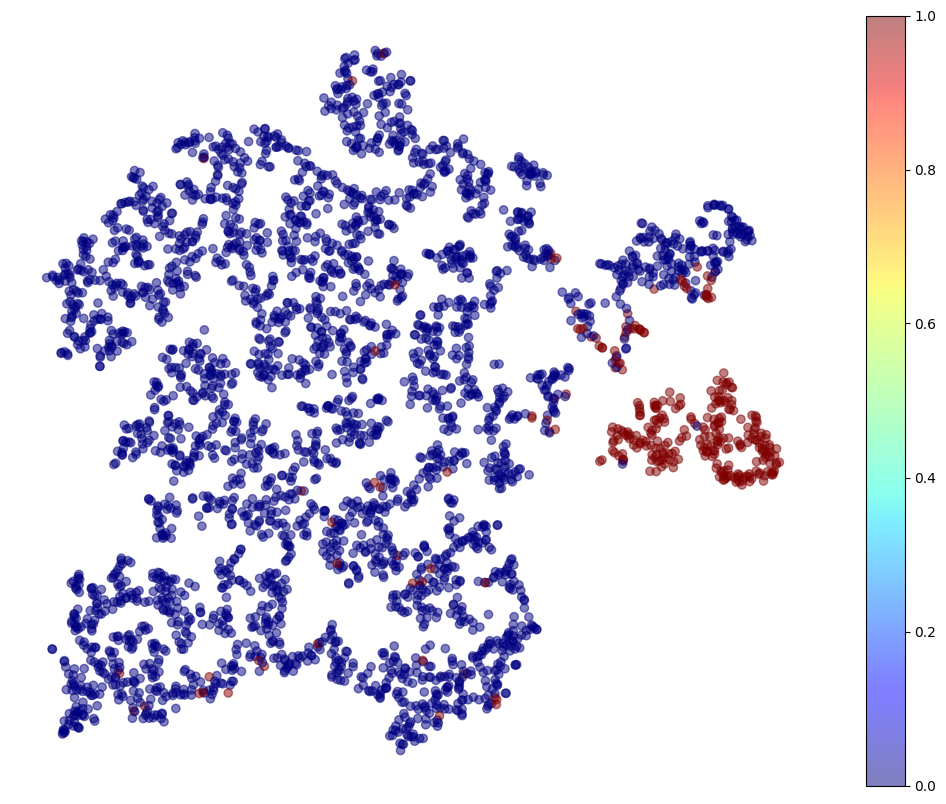

In [19]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X_test_scaled)


plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_test.astype(np.int8), cmap="jet", alpha=0.5)

plt.axis('off')
plt.colorbar()
plt.show()

#### Comment:
A large part of the positive class seem to occupy a close-knit cluster in relative space, allowing for relatively easy separation using a powerful nonlinear algorithm such as Random Forests. This part of the positive class is most likely responsible for the relatively high classification metrics throughout our experiments.

However, at least in this 2D representation produced by t-SNE, there appear to be clusters of the positive class having severe overlap with the negative class. Adjustments to the training set size and balance can increase or decrease performance with respect to the classification of these instances.